### Получаем данные

In [ ]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="local",
    symbol="BTCUSDC",
    save_dir="parquets",
    grid_resolution_ms=5000,
)
raw

,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406189,2026-02-15 23:59:35,68747.500000,68751.000000,68747.500000,68751.000000,0.090,0.834,0.000,0.834,-1.000000,...,0.445,1.749,0.030,0.084,0.003,0.018,0.010,0.002,0.012,0.002
406190,2026-02-15 23:59:40,68750.898438,68750.898438,68747.398438,68747.398438,0.256,0.069,0.069,0.000,1.000000,...,0.047,1.749,3.004,0.002,0.865,0.020,0.002,0.017,0.021,0.081
406191,2026-02-15 23:59:45,68747.398438,68747.398438,68747.398438,68747.398438,0.002,0.226,0.000,0.226,-1.000000,...,3.004,0.002,0.865,0.002,0.017,0.021,0.081,0.003,0.025,0.002
406192,2026-02-15 23:59:50,68752.101562,68758.203125,68747.500000,68753.101562,3.172,0.066,0.066,0.000,1.000000,...,0.002,0.865,0.020,0.145,0.002,0.017,0.021,0.081,0.003,0.025


### Определяем таргеты для всех моделей

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 406193/406193 [00:03<00:00, 117767.31it/s]


### Генерируем фичи для всех моделей

In [10]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.124643,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.118451,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.118451,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.115439,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.121767,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406189,4.673177,0.162000,8.923887,8.889770,0.000043,4.673170,0.133477,0.578083,0.392732,11.395686,...,0.308856,1.193079,1.581762,0.479958,0.505413,68747.500000,68751.000000,68751.000000,-0.000027,0.000051
406190,4.789844,0.210000,8.746477,8.531917,0.000069,4.789837,0.167344,-0.129906,-0.000000,-6.466825,...,0.305862,0.788968,-0.700869,-0.158648,-0.025489,68747.398438,68750.898438,68747.398438,0.000000,0.000000
406191,4.516406,0.122500,8.454927,7.977921,0.000137,4.516400,0.169734,-0.446952,-0.017957,-9.492049,...,0.289426,0.929185,-0.053730,0.406222,0.749717,68747.398438,68747.398438,68747.398438,0.000079,0.000156
406192,4.619792,0.082000,8.533253,8.036565,0.000103,4.619785,0.195234,-0.121873,-0.107145,-8.522956,...,0.266590,0.962234,-0.481483,0.105787,0.412792,68747.500000,68758.203125,68753.101562,-0.000120,0.000097


In [11]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [12]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00021
[50]	validation_0-rmse:0.00021
[100]	validation_0-rmse:0.00020
[150]	validation_0-rmse:0.00020
[200]	validation_0-rmse:0.00020
[250]	validation_0-rmse:0.00020
[300]	validation_0-rmse:0.00020
[350]	validation_0-rmse:0.00020
[400]	validation_0-rmse:0.00020
[450]	validation_0-rmse:0.00020
[500]	validation_0-rmse:0.00020
[550]	validation_0-rmse:0.00019
[600]	validation_0-rmse:0.00019
[650]	validation_0-rmse:0.00019
[700]	validation_0-rmse:0.00019
[750]	validation_0-rmse:0.00019
[800]	validation_0-rmse:0.00019
[850]	validation_0-rmse:0.00019
[900]	validation_0-rmse:0.00019
[950]	validation_0-rmse:0.00019
[1000]	validation_0-rmse:0.00019
[1050]	validation_0-rmse:0.00019
[1100]	validation_0-rmse:0.00019
[1150]	validation_0-rmse:0.00019
[1200]	validation_0-rmse:0.00019
[1250]	validation_0-rmse:0.00019
[1300]	validation_0-rmse:0.00019
[1350]	validation_0-rmse:0.00019
[1400]	validation_0-rmse:0.00019
[1450]	validation_0-rmse:0.00019
[1500]	validat

MAE                      : 0.000120
RMSE                     : 0.000194
R²                       : 0.185792
MAE / mean|Δ|            : 0.866234
RMSE / RMSE_base         : 0.902334
mean|Δ| (target)         : 0.000139

------------------------------------------------------------
Directional Accuracy     : 0.640922
Target Pos Ratio         : 0.487536
Profit Factor            : 0.813675
Avg Gain (correct)       : -0.000001
Avg Loss (incorrect)     : 0.000003

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6376, 0.6442)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (9.66e-05, 0.00121]    0.000179         0.901526    -0.000002       8124
(5.56e-05, 9.66e-05]    0.000072         0.801551    -0.000006       8123
(3.97e-05, 5.56e-05]    0.000047         0.727687     0.000005       8123


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


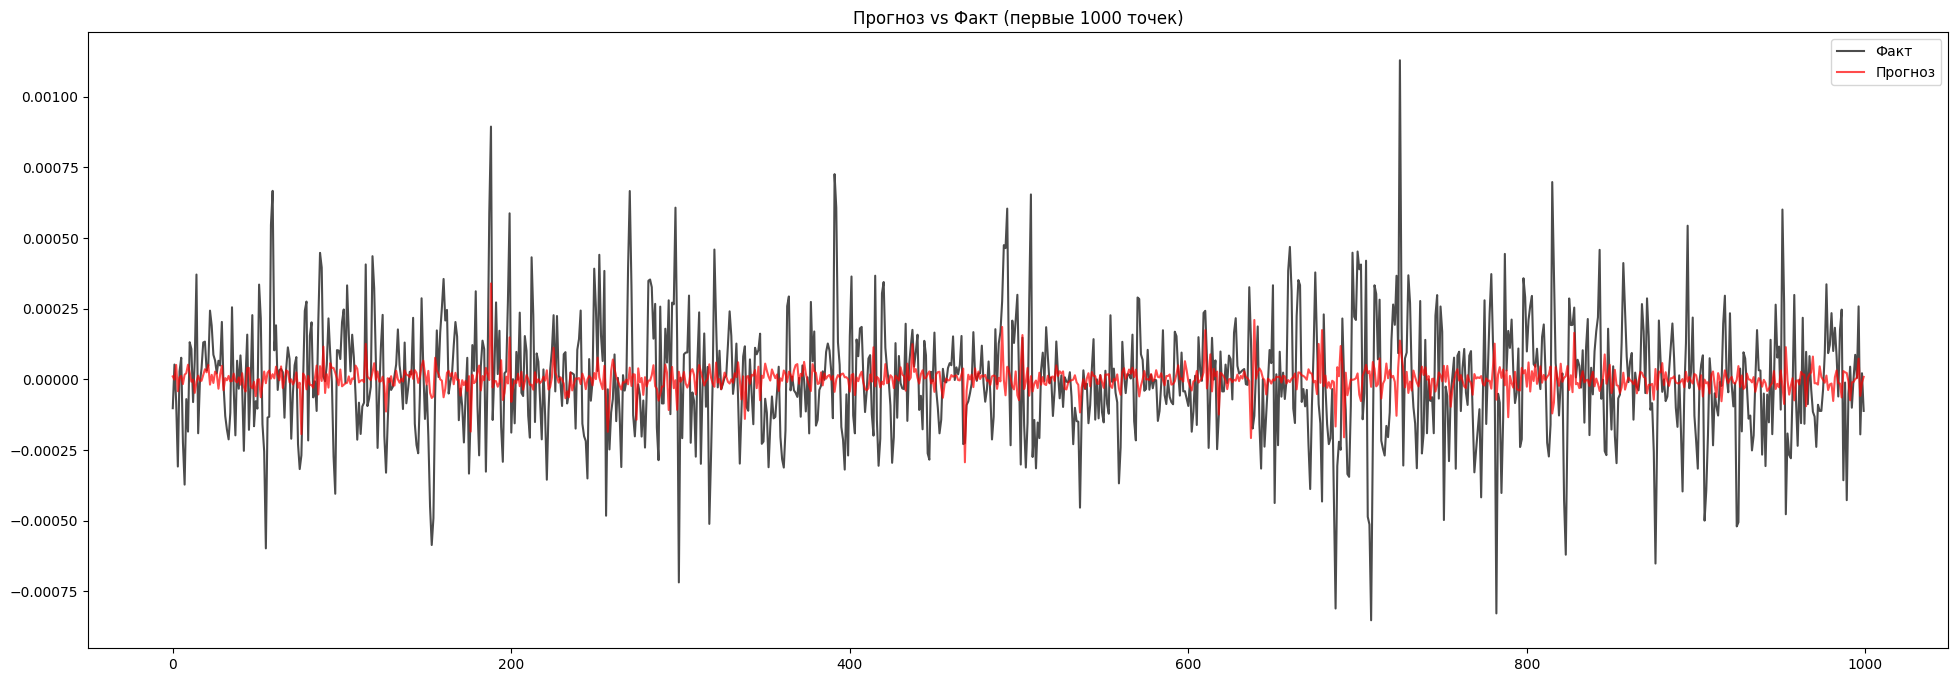

In [13]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [14]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...
[0]	validation_0-rmse:0.00024
[50]	validation_0-rmse:0.00020
[100]	validation_0-rmse:0.00018
[150]	validation_0-rmse:0.00018
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00017
[300]	validation_0-rmse:0.00017
[350]	validation_0-rmse:0.00017
[400]	validation_0-rmse:0.00017
[437]	validation_0-rmse:0.00017
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000115
RMSE                     : 0.000172
R²                       : 0.461945
MAE / mean|Δ|            : 0.544041
RMSE / RMSE_base         : 0.544531
mean|Δ| (target)         : 0.000211

------------------------------------------------------------
Directional Accuracy     : 0.921645
Target Pos Ratio         : 0.921645
Profit Factor            : 17145483875.818104
Avg Gain (correct)       : 0.000229
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9198, 0.9235)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000421, 0.00259]    0.000604         1.000000     0.000598       8124
(0.000286, 0.000421]    0.000344         0.998030     0.000336       8123
(0.000228, 0.000286]    0.000253         0.988182     0.000243    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


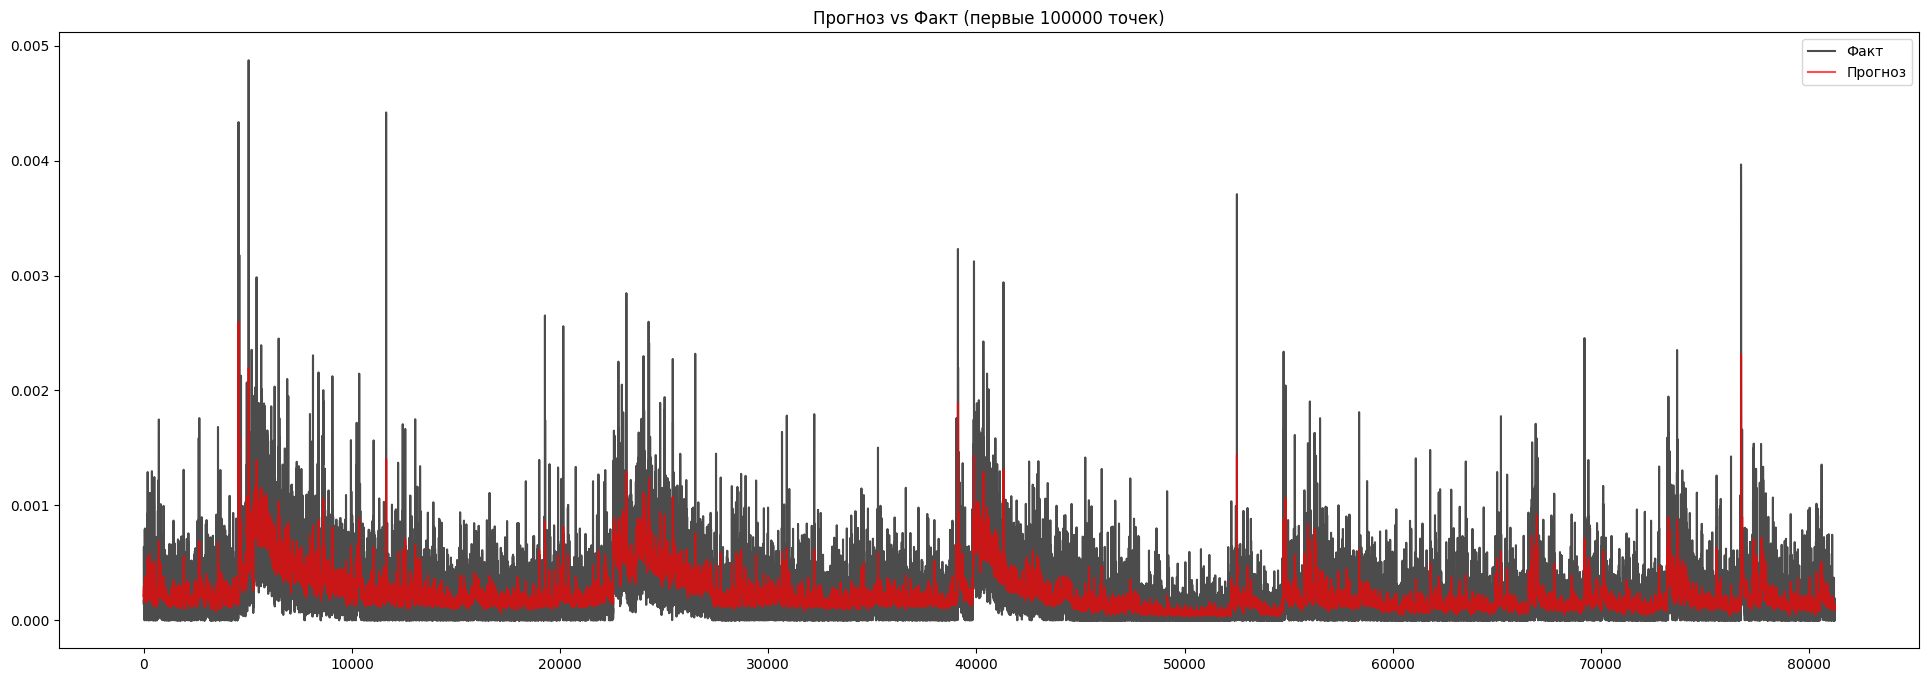

In [15]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)